<div style="background:linear-gradient(135deg,#061A33 0%,#0B2E59 45%,#00A6C0 100%); padding:44px 36px; border-radius:18px; color:#F4FBFF; font-family:'Segoe UI',Tahoma,sans-serif; box-shadow:0 8px 30px rgba(0,0,0,0.25);">
  <div style="font-size:12px; letter-spacing:4px; text-transform:uppercase; opacity:0.75; margin-bottom:10px;">BinX Tech &nbsp;•&nbsp; AI &amp; Machine Learning Internship &nbsp;•&nbsp; Phase 3 Capstone</div>
  <div style="font-size:38px; font-weight:800; line-height:1.15;">🩺 Week 8 · Day 1</div>
  <div style="font-size:22px; font-weight:400; opacity:0.92; margin-top:4px;">Sprint 3 Planning &amp; NLP Preprocessing</div>
  <div style="margin-top:20px; display:flex; flex-wrap:wrap; gap:8px;">
    <span style="background:#00C2D1; color:#04263A; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🚀 SPRINT 3 — DAY 1 / 5</span>
    <span style="background:#FFC857; color:#4A3400; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">⏱️ 8 HOURS</span>
    <span style="background:#8CE99A; color:#0B3D1E; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🔤 NLP FUNDAMENTALS</span>
    <span style="background:#D0BFFF; color:#2E1065; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">❤️ CARDIAC MONITORING THREAD</span>
  </div>
</div>

<div style="text-align:center; color:#7C8B9B; font-size:13px; font-style:italic; margin-top:14px;">
"Every model that will ever face the real world first has to survive the mess of raw human language."
</div>

<div style="border-left:5px solid #00A6C0; background:#F0FBFD; padding:18px 22px; border-radius:0 10px 10px 0; margin:18px 0;">
<h3 style="margin-top:0; color:#0B2E59;">📖 The Story So Far</h3>
<p style="margin-bottom:0; color:#233; line-height:1.6;">
Sprint 2 closed with a trained, validated model that beats the Week 6 baseline. That was the hard part — proving the idea works.
Sprint 3 is about something less glamorous but just as critical: turning that idea into a <b>trustworthy, end-to-end system</b>.
Today we open a new chapter in that system's life — <b>text</b>. Not every signal a model needs arrives as a clean number in a
spreadsheet column; a lot of it arrives as messy, inconsistent, human-written text. Before any of it can reach a model,
it has to be tamed. That taming process is called <b>NLP preprocessing</b>, and it's the whole story of Day&nbsp;1.
</p>
</div>

<div style="background:#0B2E59; border-radius:14px; padding:22px 26px; color:#EAF6FA;">
<h3 style="margin-top:0; color:#8CE9F4;">🎯 Learning Objectives</h3>
<table style="width:100%; border-collapse:collapse; color:#EAF6FA;">
<tr><td style="padding:8px 10px; font-size:20px;">🧩</td><td style="padding:8px 10px;">Preprocess raw text for ML: tokenization, cleaning, and stop-word removal.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🌱</td><td style="padding:8px 10px;">Apply lemmatization appropriately — and know when <i>not</i> to over-clean.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🗺️</td><td style="padding:8px 10px;">Plan Sprint 3: define the integration &amp; evaluation backlog.</td></tr>
</table>
</div>

## 1.1 &nbsp;Sprint 3 Planning

Day 1 opens with **Sprint Planning**. Sprint 3's goal: integrate everything built so far into one complete pipeline and
evaluate it rigorously — turning a trained model into a finished, deployable component ready for Sprint 4.

**Sprint 3 backlog (this week's plan):**

| # | Backlog item | Lands on |
|---|---|---|
| 1 | Text preprocessing pipeline (tokenize → clean → lemmatize) | Day 1 |
| 2 | Text representation: TF-IDF vs. word embeddings | Day 2 |
| 3 | Image preprocessing + augmentation pipeline (OpenCV) | Day 3 |
| 4 | End-to-end `predict()` pipeline + error analysis | Day 4 |
| 5 | Full evaluation, SHAP explainability, Sprint Review & Retrospective | Day 5 |

**Carried forward from the Sprint 2 Retrospective:** *`[ ✍️ add your specific Sprint 2 retro action item here ]`*

<div style="background:#FFF7E6; border:1px solid #FFC857; border-radius:10px; padding:14px 18px; margin:14px 0;">
<b>🎬 Director's Commentary</b><br>
<span style="color:#5B4A00;">Planning feels like admin work, but skipping it is exactly how a sprint turns into five days of
unfocused notebook-editing. Two minutes writing the backlog above saved me from re-deciding "what am I doing today?"
every single morning this week.</span>
</div>

## 1.2 &nbsp;Why Text Needs Preprocessing

A model cannot read raw text — it needs numbers. But before text becomes numbers, it has to be cleaned and standardized.
Without that step, `"Good"`, `"good"`, and `"good!"` would be treated as **three completely different tokens**, even though
a human reads them as the same word. NLP preprocessing is the pipeline that turns messy human language into a clean,
consistent form — ready for numerical representation (which we'll build on Day 2).

## 1.3 &nbsp;Tokenization

Tokenization splits text into units (**tokens**) — usually words, sometimes sub-words or characters. It's the first step
of every NLP pipeline. Let's run the textbook example, then move straight into real data.

In [1]:
# --- Setup ---
import nltk, re, string
import pandas as pd

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize(token):
    # try verb form first ("helped" -> "help"), fall back to noun form ("symptoms" -> "symptom")
    v = lemmatizer.lemmatize(token, pos='v')
    return v if v != token else lemmatizer.lemmatize(token, pos='n')

print("Environment ready ✅")

Environment ready ✅


In [2]:
# Textbook example, straight from the curriculum
example = "The movie was great!"
print(word_tokenize(example))
# -> ['The', 'movie', 'was', 'great', '!']

['The', 'movie', 'was', 'great', '!']


### From toy example to real data

Our capstone (Cardiac Patient Monitoring) is tabular, so it has no text column of its own — but the curriculum is
explicit: *"take a raw text sample (or the project's text data)."* To keep practicing on real, messy text instead of
invented sentences, we reuse the **UCI Drug Review dataset** from Week 7 · Day 4 — it keeps the health-domain thread of
this internship going, and drug reviews are exactly the kind of noisy, opinionated human text preprocessing exists for.

In [3]:
import os

DATA_PATH = "drugsComTrain_raw.csv"  # same file used in Week 7 · Day 4

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    corpus_samples = df['review'].dropna().sample(min(300, len(df)), random_state=42).tolist()
    print(f"Loaded {len(df):,} reviews from the Week 7 dataset — sampling {len(corpus_samples)} of them for the charts below.\n")
else:
    # Fallback corpus so this notebook still runs standalone without the Week 7 CSV on disk.
    # Deliberately reuses vocabulary across sentences so the frequency chart later is meaningful.
    corpus_samples = [
        "This medication did NOT help my symptoms at all, I was very disappointed.",
        "\"Amazing results!\" My doctor said it's the best option for my condition.",
        "I've been taking this for 3 months and it hasn't worked well for me.",
        "Great drug, no side effects, and it really helped with my anxiety.",
        "The pills tasted awful and I felt worse after the first week.",
        "My doctor recommended this medication for chronic pain, and it really did help.",
        "No side effects so far, but I am not sure if it is actually working.",
        "This drug helped reduce my pain significantly within the first week.",
        "I stopped taking it because the side effects were too strong for me.",
        "My doctor increased the dose and now the medication works much better.",
        "It did not help with my anxiety symptoms, unfortunately.",
        "Amazing improvement in my symptoms after just one week on this medication.",
        "I felt no side effects, and my doctor is happy with the results.",
        "This medication caused severe side effects, so my doctor changed my dose.",
        "Great medication overall, it helped with both pain and anxiety.",
        "I am disappointed because the dose increase did not help at all.",
        "The doctor said the side effects should go away after the first week.",
        "This drug really helped me manage my chronic symptoms every day.",
        "No improvement in my condition even after increasing the dose.",
        "My symptoms got much better once my doctor adjusted the medication dose.",
    ]
    print("drugsComTrain_raw.csv not found locally — using a small built-in corpus instead.\n")

raw_samples = corpus_samples[:5]  # a small, readable slice for the walkthrough below
for i, s in enumerate(raw_samples, 1):
    print(f"{i}. {s}")

drugsComTrain_raw.csv not found locally — using a small built-in corpus instead.

1. This medication did NOT help my symptoms at all, I was very disappointed.
2. "Amazing results!" My doctor said it's the best option for my condition.
3. I've been taking this for 3 months and it hasn't worked well for me.
4. Great drug, no side effects, and it really helped with my anxiety.
5. The pills tasted awful and I felt worse after the first week.


## 1.4 &nbsp;Cleaning and Normalization

Standard cleaning steps make tokens consistent: **lowercasing**, **punctuation removal**, **stop-word removal**, and
**lemmatization** (reducing a word to its dictionary base form — preferred over the cruder *stemming*, because it
produces real words and preserves meaning).

Let's build the "textbook" pipeline first, exactly as described — then see what it does to a real review.

In [4]:
stop_words_default = set(stopwords.words('english'))

def clean_naive(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_default]
    tokens = [lemmatize(t) for t in tokens]
    return tokens

sample_text = raw_samples[0]
print("Original:     ", sample_text)
print("Naive cleaned:", clean_naive(sample_text))

Original:      This medication did NOT help my symptoms at all, I was very disappointed.


Naive cleaned: ['medication', 'help', 'symptom', 'disappoint']


<div style="background:#FFF0F0; border:1px solid #FF8787; border-radius:10px; padding:16px 20px; margin:16px 0;">
<b>⚠️ Preprocessing choices are task-dependent</b><br><br>
Look closely at the output above. If the sample contains a negation ("did <b>NOT</b> help"), the naive pipeline just
<b>deleted it</b> — because <code>"not"</code> sits inside NLTK's default English stop-word list. A review that says a
drug <i>did not help</i> can come out of "cleaning" looking like it said the drug <i>did help</i>. For any task where
polarity matters (sentiment, side-effect reporting, and — closer to home — clinical notes for the Cardiac Monitoring
project like <i>"patient denies chest pain"</i> vs. <i>"patient reports chest pain"</i>), that single dropped word
flips the meaning of the entire sentence. Always check that cleaning preserves the signal your task actually needs.
</div>

### Fixing it: a task-aware stop-word list

The fix isn't to abandon stop-word removal — it's to remove the *right* words for *this* task. We carve negation terms
out of the stop-word list before applying it.

In [5]:
negation_words = {
    "not", "no", "nor", "never",
    "don", "didn", "doesn", "isn", "wasn", "won", "cant", "cannot", "couldnt", "shouldnt", "wouldnt",
}
stop_words_task_aware = stop_words_default - negation_words

def clean_task_aware(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_task_aware]
    tokens = [lemmatize(t) for t in tokens]
    return tokens

print("Original:          ", sample_text)
print("Naive cleaned:      ", clean_naive(sample_text))
print("Task-aware cleaned: ", clean_task_aware(sample_text))

Original:           This medication did NOT help my symptoms at all, I was very disappointed.
Naive cleaned:       ['medication', 'help', 'symptom', 'disappoint']
Task-aware cleaned:  ['medication', 'not', 'help', 'symptom', 'disappoint']


<div style="background:#EBFBEE; border:1px solid #8CE99A; border-radius:10px; padding:14px 18px; margin:14px 0;">
<b>✅ Result</b><br>
<span style="color:#0B3D1E;">The negation survives. The sentence still means what it originally meant — which is the
entire point of preprocessing: reduce noise <i>without</i> destroying the signal the downstream model actually needs.</span>
</div>

## 🧪 Hands-On Lab: Sprint 3 Kickoff &amp; Text Cleaning

| Step | Task | Status |
|---|---|---|
| 1 | Complete Sprint 3 planning and select backlog tasks | ✅ done above (§1.1) |
| 2 | Take a raw text sample and tokenize it | ✅ done above (§1.3) |
| 3 | Apply a full cleaning pipeline (lowercase, punctuation, stop words, lemmatize) | ✅ done above (§1.4) |
| 4 | Verify cleaning preserves task-critical words, and document the choice | 👇 below |

In [6]:
comparison = pd.DataFrame({
    "raw_text": raw_samples,
    "naive_cleaned": [" ".join(clean_naive(t)) for t in raw_samples],
    "task_aware_cleaned": [" ".join(clean_task_aware(t)) for t in raw_samples],
})
pd.set_option("display.max_colwidth", 60)
comparison

,raw_text,naive_cleaned,task_aware_cleaned
0,"This medication did NOT help my symptoms at all, I was v...",medication help symptom disappoint,medication not help symptom disappoint
1,"""Amazing results!"" My doctor said it's the best option f...",amaze result doctor say best option condition,amaze result doctor say best option condition
2,I've been taking this for 3 months and it hasn't worked ...,ive take 3 month hasnt work well,ive take 3 month hasnt work well
3,"Great drug, no side effects, and it really helped with m...",great drug side effect really help anxiety,great drug no side effect really help anxiety
4,The pills tasted awful and I felt worse after the first ...,pill taste awful felt worse first week,pill taste awful felt worse first week


### 📊 Seeing the pipeline, not just reading it

Numbers in a table are easy to skim past. Two quick charts make the same evidence impossible to miss: how much each
stage actually shrinks the text, and what vocabulary survives into Day 2.

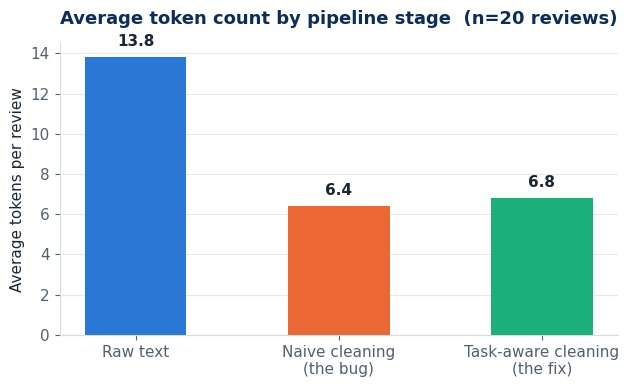

Keeping negations intact costs only 0.4 extra token(s) on average per review — essentially free compared to the meaning it protects.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

plt.rcParams.update({
    "font.size": 11,
    "axes.edgecolor": "#D8DCE1",
    "axes.linewidth": 0.8,
    "text.color": "#1A2733",
    "axes.labelcolor": "#1A2733",
    "xtick.color": "#52616F",
    "ytick.color": "#52616F",
})

# --- Chart 1: average token count per pipeline stage ---
stage_names = ["Raw text", "Naive cleaning\n(the bug)", "Task-aware cleaning\n(the fix)"]
stage_colors = ["#2a78d6", "#eb6834", "#1baf7a"]

avg_counts = [
    sum(len(word_tokenize(t)) for t in corpus_samples) / len(corpus_samples),
    sum(len(clean_naive(t)) for t in corpus_samples) / len(corpus_samples),
    sum(len(clean_task_aware(t)) for t in corpus_samples) / len(corpus_samples),
]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(stage_names, avg_counts, width=0.5, color=stage_colors, edgecolor="none", zorder=3)

for rect, val in zip(bars, avg_counts):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.4, f"{val:.1f}",
            ha="center", va="bottom", fontsize=11, color="#1A2733", fontweight="bold")

ax.set_ylabel("Average tokens per review")
ax.set_title(f"Average token count by pipeline stage  (n={len(corpus_samples)} reviews)",
             fontsize=13, fontweight="bold", color="#0B2E59", pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", color="#E7EAED", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

extra_tokens = avg_counts[2] - avg_counts[1]
print(f"Keeping negations intact costs only {extra_tokens:.1f} extra token(s) on average per review — "
      f"essentially free compared to the meaning it protects.")

<div style="border-left:5px solid #1baf7a; background:#F0FBF6; padding:14px 20px; border-radius:0 10px 10px 0; margin:14px 0;">
The task-aware pipeline barely costs anything in compression — a fraction of a token on average — for a fix that
prevents entire sentences from silently flipping meaning. That trade is essentially free.
</div>

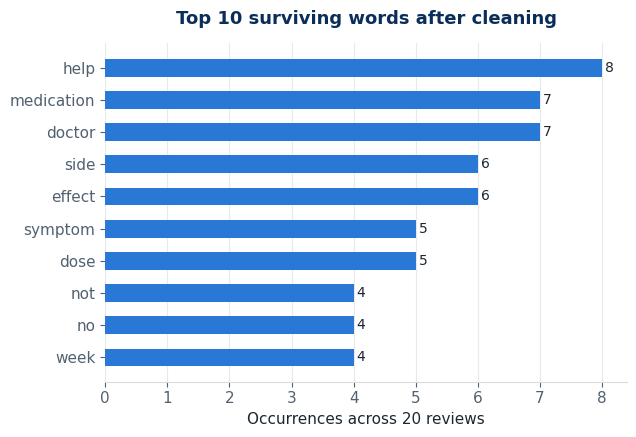

In [8]:
# --- Chart 2: most frequent surviving words after task-aware cleaning ---
all_tokens = [tok for t in corpus_samples for tok in clean_task_aware(t)]
top_words = Counter(all_tokens).most_common(10)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
y_pos = range(len(words))
ax.barh(y_pos, counts, height=0.55, color="#2a78d6", edgecolor="none", zorder=3)

for i, val in enumerate(counts):
    ax.text(val + 0.05, i, str(val), va="center", fontsize=10, color="#1A2733")

ax.set_yticks(y_pos)
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel(f"Occurrences across {len(corpus_samples)} reviews")
ax.set_title("Top 10 surviving words after cleaning", fontsize=13, fontweight="bold", color="#0B2E59", pad=14)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", color="#E7EAED", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 📝 Documentation: preprocessing choices for this project

- **Tokenizer:** `nltk.word_tokenize` — word-level tokens, matches the Week 7 sub-word discussion for context but keeps
  this pipeline simple and inspectable.
- **Case & punctuation:** fully normalized (lowercase, punctuation stripped) — safe for this task, no signal lost.
- **Stop words:** NLTK's default English list, **minus negation terms** (`not`, `no`, `never`, contracted negatives)
  — because flipping a review's polarity by deleting "not" is a correctness bug, not a simplification.
- **Lemmatization over stemming:** chosen to keep tokens as real dictionary words, which matters when a human (or SHAP,
  later in the sprint) needs to read and trust the output.
- **Why this matters beyond Day 1:** the same negation-awareness principle is the basis of tools like **NegEx**, used in
  real clinical NLP to detect negated findings in medical notes — directly relevant if the Cardiac Monitoring project
  ever ingests physician notes instead of only structured vitals.

<div style="display:flex; flex-wrap:wrap; gap:8px; margin:18px 0;">
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🐍 NLTK / spaCy</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🐼 Pandas</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📓 Jupyter / Colab</span>
<span style="background:#0B2E59; color:#EAF6FA; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔗 Git &amp; GitHub</span>
</div>

<div style="background:linear-gradient(135deg,#0B2E59,#061A33); border-radius:14px; padding:24px 28px; color:#EAF6FA; margin-top:10px;">
<h3 style="margin-top:0; color:#8CE9F4;">✅ Day 1 — Closed Out</h3>
<p style="line-height:1.6;">
Raw, messy review text is now clean, consistent, and — critically — still <i>correct</i>. That's the whole job of
preprocessing: reduce noise without erasing signal. Tomorrow (<b>Day 2</b>) we turn these clean tokens into numbers,
comparing TF-IDF against word embeddings so the model can finally read them.
</p>
<div style="text-align:right; font-size:13px; opacity:0.7; margin-top:10px;">Week 8 · Sprint 3 · Day 1 of 5 → <b>Day 2: Text Representation</b></div>
</div>